In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 



In [2]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [3]:
precision=1e-10

In [4]:
output_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS10000'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [5]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [6]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [7]:

    
entropy_cutoff


0.27543487302324027

In [8]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [9]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [10]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy
AAACAAGCAAACATGT-1,1,0.0,0.000000,1,0.0,0.000000,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000645
AAACAAGCAAACCTAG-1,104,7.0,6.730769,104,7.0,6.730769,0.009912
AAACAAGCAAAGAAGC-1,486,30.0,6.172840,486,30.0,6.172840,0.021829
AAACAAGCAAAGGTAA-1,1,1.0,100.000000,1,1.0,100.000000,NaN


## Load CR's barcodes info 

In [11]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [12]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)

# See Tn5 insersion frequency distribution at different entropy levels

## For real cells 

In [13]:
all_df_cr = all_df.loc[~all_df['Cluster'].isna()].copy()

In [14]:
cr_bcs = all_df_cr.index.tolist()
Ncr_bcs = len(cr_bcs)
print(f'Number of cell barcodes: {Ncr_bcs}')

Number of cell barcodes: 1959


In [15]:
np.random.seed(19) # seed 6 gives a cell with high depth 
#seed 7 is intersting too
sample_bc = np.random.choice(cr_bcs, size=1, replace=False)

all_df_cr.loc[sample_bc]

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,Cluster,log(total_fragments),log(entropy)
CTAGCTATCAATCGGG-1,9429,5925.0,62.838053,9429,5957.0,63.177431,0.339623,4.0,3.974466,-0.469003


In [16]:
bc_insert_freq = tn5_insert_freq[sample_bc[0]].toarray()
bc_seq_depth = all_df_cr.loc[sample_bc, 'total_fragments_peaks'].iloc[0]
bc_logentropy_val = all_df_cr.loc[sample_bc, 'log(entropy)'].iloc[0]
bc_frag_overlap = all_df_cr.loc[sample_bc, 'frag_overlap_entropy_peaks%'].iloc[0]

np.unique(bc_insert_freq, return_counts=True),  print(f"seq-depth: {bc_seq_depth}. log(entropy): {bc_logentropy_val}. frag-overlap: {bc_frag_overlap}")

seq-depth: 9429. log(entropy): -0.46900339948271363. frag-overlap: 62.8380528157811


((array([ 0,  1,  2,  3,  4,  5,  6,  8, 10, 11, 12, 13, 16], dtype=int32),
  array([23734,    32,   817,    11,   197,     3,    70,    22,     6,
             1,     1,     1,     1])),
 None)

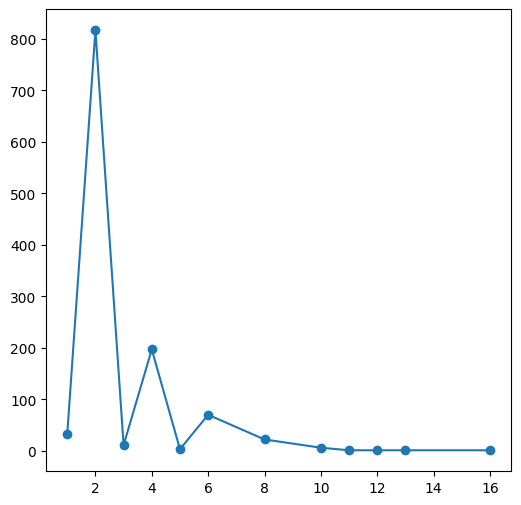

In [17]:
val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(val[1:], freq[1:], marker='o' )#, marker='0', linestyle='None')

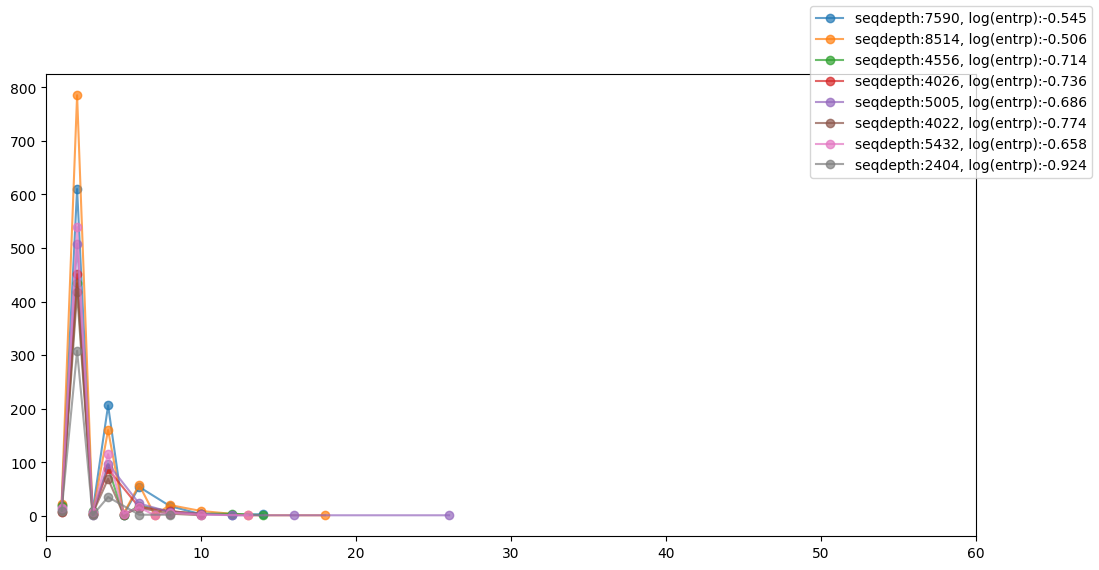

In [18]:

fig, ax = plt.subplots(1,1, figsize=(12,6))

for i in range(20, 30):
    np.random.seed(i) # seed 6 gives a cell with high depth 
    #seed 7 is intersting too
    sample_bc = np.random.choice(cr_bcs, size=1, replace=False)

    bc_insert_freq = tn5_insert_freq[sample_bc[0]].toarray()
    bc_seq_depth = all_df_cr.loc[sample_bc, 'total_fragments_peaks'].iloc[0]
    bc_logentropy_val = all_df_cr.loc[sample_bc, 'log(entropy)'].iloc[0]
    bc_frag_overlap = all_df_cr.loc[sample_bc, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    if bc_seq_depth > 10000:
        continue
    
    val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)

    ax.plot(val[1:], freq[1:], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)}', alpha=0.7)
    ax.set_xlim(0, 60)
    
fig.legend()
    

## For bad-quality cell or empty barcodes 

In [19]:
depth_threshold = 2000
all_df_empty = all_df.loc[all_df['Cluster'].isna() & (all_df['total_fragments_peaks'] > depth_threshold)].copy()
len(all_df_empty)

58

In [20]:
cr_empties = all_df_empty.index.tolist()


In [21]:
np.random.seed(19)
sample_empty = np.random.choice(cr_empties, size=1, replace=False)

all_df_empty.loc[sample_empty]

sample_empty[0] in tn5_insert_freq.keys()

True

In [22]:
empty_insert_freq = tn5_insert_freq[sample_empty[0]].toarray()
empty_seq_depth = all_df_empty.loc[sample_empty, 'total_fragments_peaks'].iloc[0]
empty_logentropy_val = all_df_empty.loc[sample_empty, 'log(entropy)'].iloc[0]
empty_frag_overlap = all_df_empty.loc[sample_empty, 'frag_overlap_entropy_peaks%'].iloc[0]

np.unique(empty_insert_freq, return_counts=True),  print(f"seq-depth: {empty_seq_depth}. log(entropy): {empty_logentropy_val}. frag-overlap: {empty_frag_overlap}")

seq-depth: 6917. log(entropy): -0.5491965400957189. frag-overlap: 61.327164955905744


((array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10], dtype=int32),
  array([23933,    24,   724,     6,   163,     2,    33,     2,     8,
             1])),
 None)

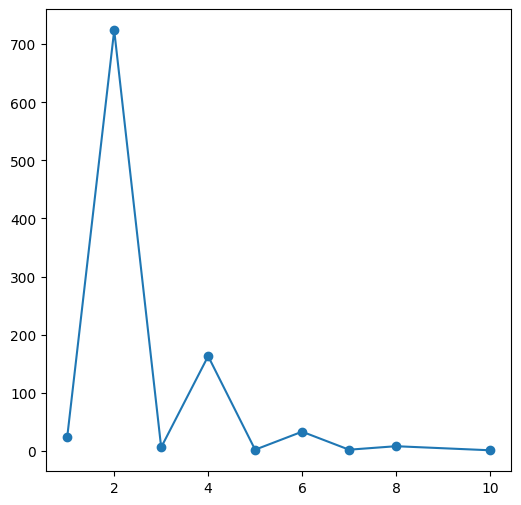

In [23]:
val, freq = np.unique(tn5_insert_freq[sample_empty[0]].toarray(), return_counts=True)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(val[1:], freq[1:], marker='o' )#, marker='0', linestyle='None')

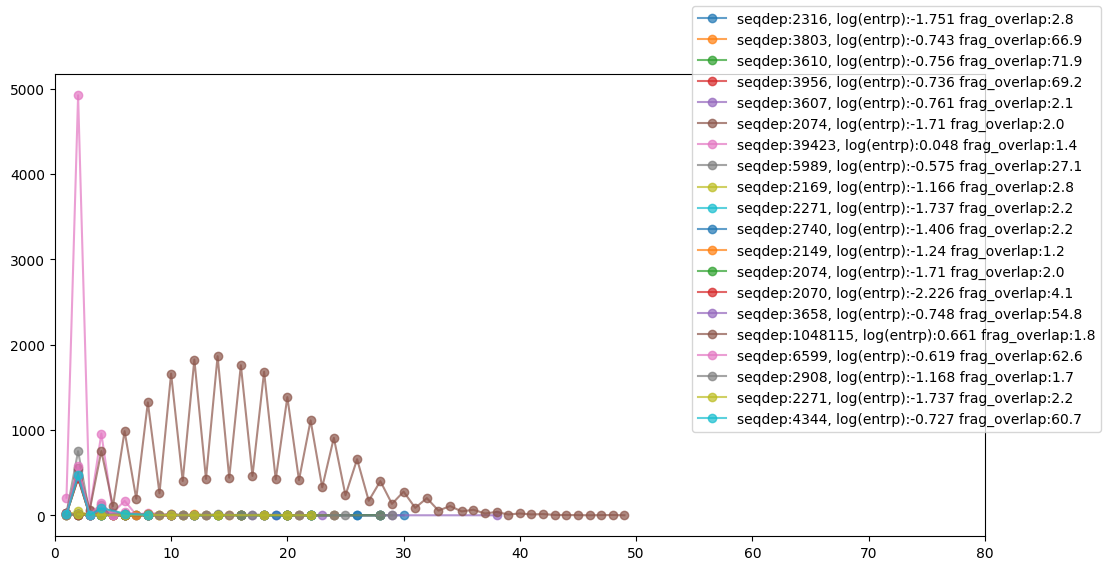

In [25]:
fig, ax = plt.subplots(1,1, figsize=(12,6))

for i in range(100, 120):
    np.random.seed(i)
    sample_empty = np.random.choice(cr_empties, size=1, replace=False)

    empty_insert_freq = tn5_insert_freq[sample_empty[0]].toarray()
    empty_seq_depth = all_df_empty.loc[sample_empty, 'total_fragments_peaks'].iloc[0]
    empty_logentropy_val = all_df_empty.loc[sample_empty, 'log(entropy)'].iloc[0]
    empty_frag_overlap = all_df_empty.loc[sample_empty, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    #if empty_logentropy_val > np.log10(entropy_cutoff + precision):
    # if np.log10(entropy_cutoff+ precision) < empty_logentropy_val and empty_logentropy_val < 0:
    #if -0.1 < empty_logentropy_val and empty_logentropy_val < 0.2 and empty_frag_overlap > 30:
    val, freq = np.unique(tn5_insert_freq[sample_empty[0]].toarray(), return_counts=True)
    ax.plot(val[1:], freq[1:], marker='o', label=f'seqdep:{empty_seq_depth}, log(entrp):{np.round(empty_logentropy_val, 3)} frag_overlap:{np.round(empty_frag_overlap, 1)}', alpha=0.7)


    ax.set_xlim(0, 80)
fig.legend()
    

## For simulated doublets

In [26]:
cluster_barcode_subdir = os.path.join(output_dir, 'cluster_barcodes')
#  load insert frequency per barcode toå prep for doublet simulation
insert_frequency_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')
with open(insert_frequency_file, 'rb') as file:
    insert_record = pickle.load(file)
    
cluster_barcode_file_list = os.listdir(cluster_barcode_subdir)

In [27]:
if len(cluster_barcode_file_list) >= 2:
    ## provide barcode list for population 1    
    cluster1_barcode_file = os.path.join(cluster_barcode_subdir, cluster_barcode_file_list[0])
    cluster1_barcode_list = pd.read_csv(cluster1_barcode_file, header=None)[0].tolist()    
    ## provide barcode list for population 2
    cluster2_barcode_file = os.path.join(cluster_barcode_subdir, cluster_barcode_file_list[1])
    cluster2_barcode_list = pd.read_csv(cluster2_barcode_file, header=None)[0].tolist()

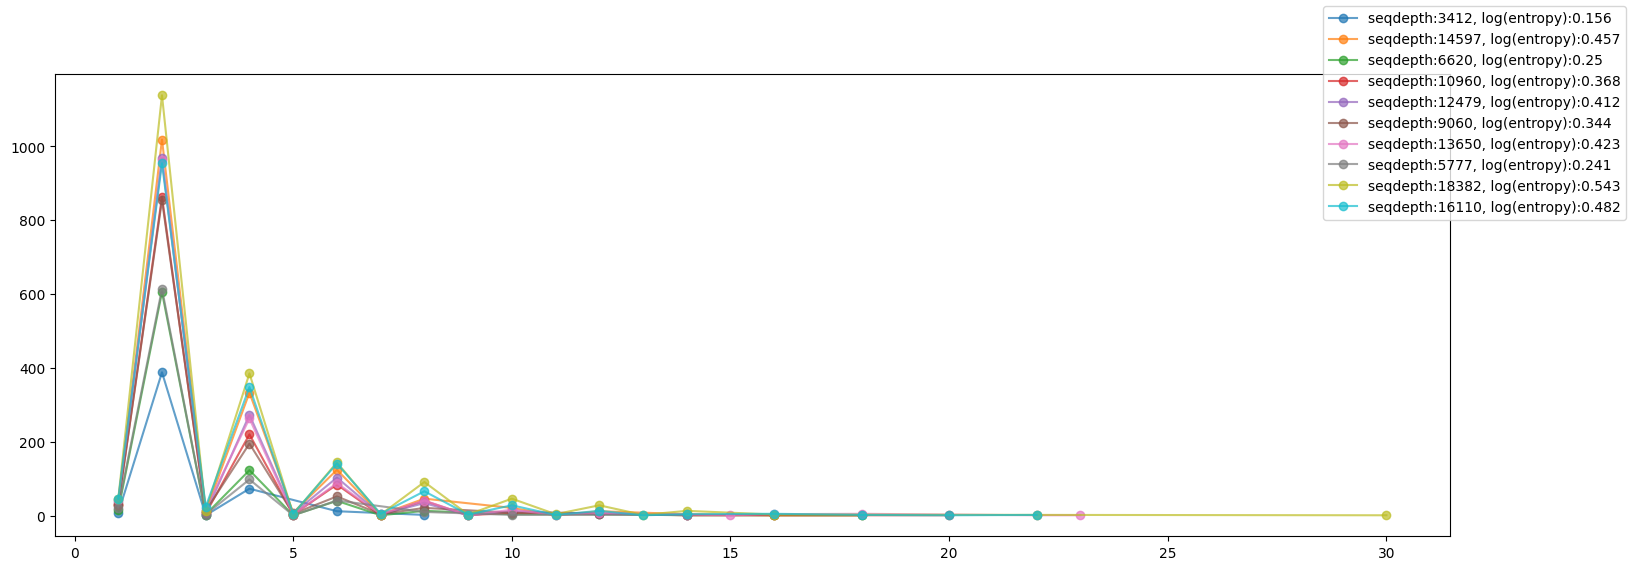

In [28]:
Nsim = 10 
## Simulate doublets and calculate entropy 
entropies_sim_doublets = {}
insertions_sim_doublets = {}
seq_depth_sim_doublets = {}


fig, ax = plt.subplots(1,1, figsize=(18,6))

for i in range(Nsim):
    # randomly select one barcode from each population
    bc1 = np.random.choice(cluster1_barcode_list)
    bc2 = np.random.choice(cluster2_barcode_list)
    # simulate doublet insertions -- add insertion frequencies
    sim_insertions = insert_record[bc1].toarray() + insert_record[bc2].toarray()
    
    insertions_sim_doublets[f'sim_doublet_{i}'] = sim_insertions
    # calculate entropy 
    occur, freq = np.unique(sim_insertions, return_counts=True)
    freq_norm = freq / np.sum(freq)
    entropy = -np.sum(freq_norm * np.log2(freq_norm + precision))
    seq_depth = all_df_cr.loc[[bc1, bc2], 'total_fragments_peaks'].sum()

    entropies_sim_doublets[f'sim_doublet_{i}'] = entropy
    seq_depth_sim_doublets[f'sim_doublet_{i}'] = seq_depth
    insertions_sim_doublets[f'sim_doublet_{i}'] = sim_insertions


    ax.plot(occur[1:], freq[1:], marker='o', label=f'seqdepth:{seq_depth}, log(entropy):{np.round(entropy, 3)}', alpha=0.7)

fig.legend()


sim_doublet_df = pd.DataFrame([entropies_sim_doublets, seq_depth_sim_doublets]).T
sim_doublet_df.columns = ['entropy', 'total_fragments']
sim_doublet_df['log(entropy)'] = np.log10(sim_doublet_df['entropy'] + precision)
sim_doublet_df['log(total_fragments)'] = np.log10(sim_doublet_df['total_fragments'] + precision)

## Check bcs that passed entropy threshold but not CR-calling 

###  Want to show our method is better than CR's |fragments_overlap_entropy_peaks| method


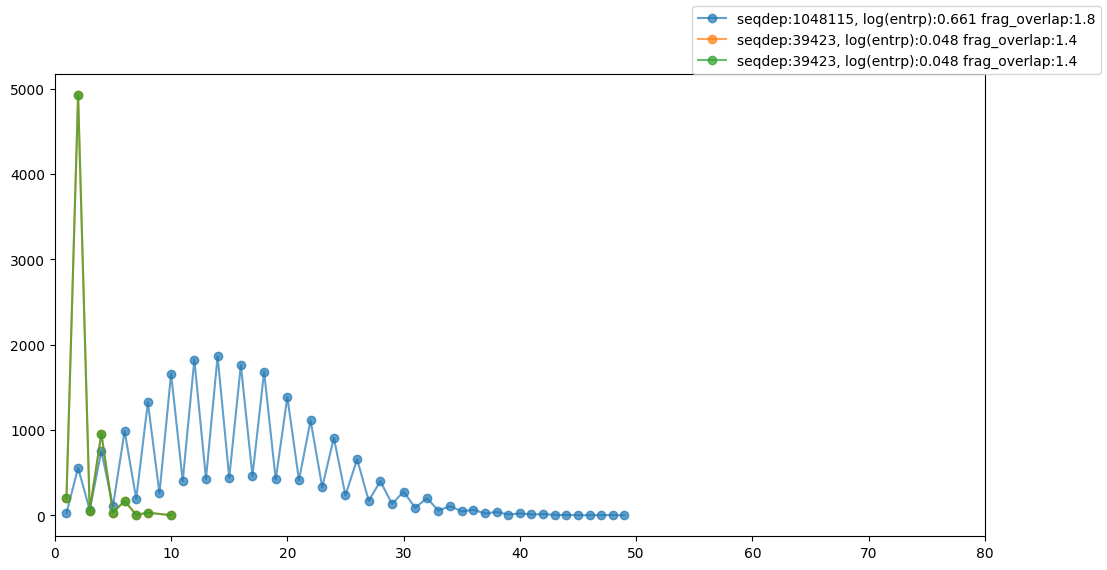

In [35]:
all_df_empty = all_df.loc[all_df['Cluster'].isna() ].copy()

fig, ax = plt.subplots(1,1, figsize=(12,6))

# BCs that passed entropy threshold but not CR-calling
bc_sample_list = all_df_empty.loc[all_df_empty['log(entropy)'] > np.log10(entropy_cutoff + precision) ].index.tolist()

for i in range(80, 84):
    np.random.seed(i)
    sample_empty = np.random.choice(bc_sample_list, size=1, replace=False)

    empty_insert_freq = tn5_insert_freq[sample_empty[0]].toarray()
    empty_seq_depth = all_df_empty.loc[sample_empty, 'total_fragments_peaks'].iloc[0]
    empty_logentropy_val = all_df_empty.loc[sample_empty, 'log(entropy)'].iloc[0]
    empty_frag_overlap = all_df_empty.loc[sample_empty, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    #if empty_logentropy_val > np.log10(entropy_cutoff + precision):
    #if np.log10(entropy_cutoff+ precision) < empty_logentropy_val and empty_logentropy_val < 0:
    if -0.1 < empty_logentropy_val:
        val, freq = np.unique(tn5_insert_freq[sample_empty[0]].toarray(), return_counts=True)
        ax.plot(val[1:], freq[1:], marker='o', label=f'seqdep:{empty_seq_depth}, log(entrp):{np.round(empty_logentropy_val, 3)} frag_overlap:{np.round(empty_frag_overlap, 1)}', alpha=0.7)


    ax.set_xlim(0, 80)
fig.legend()

## Plot good barcode and empty/bad barcodes in the same plot 

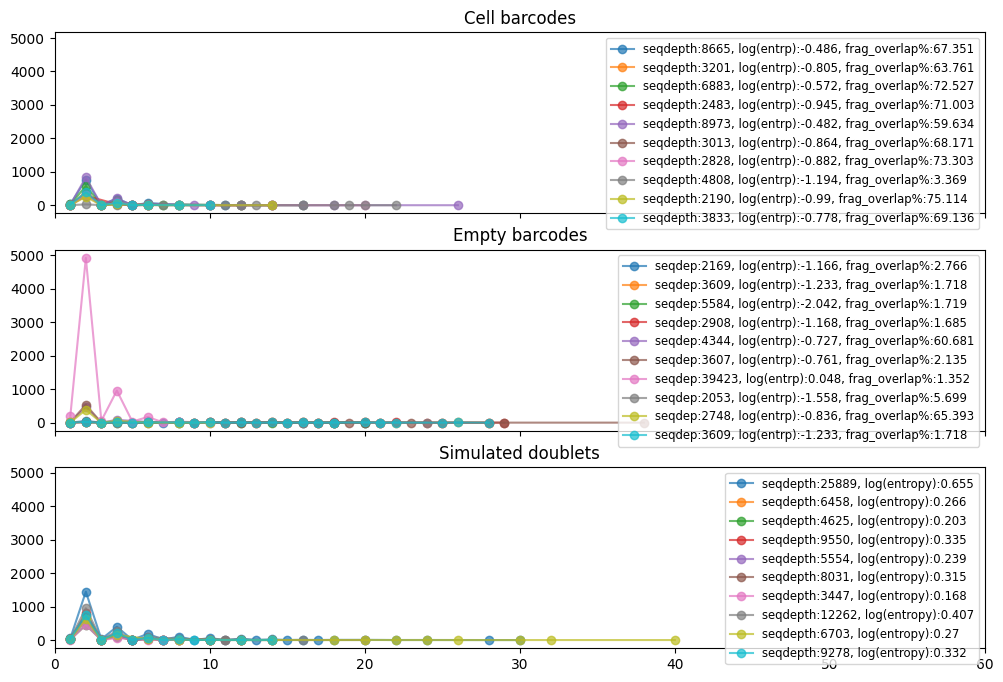

In [36]:

fig, ax = plt.subplots(3,1, figsize=(12,8), sharex=True, sharey=True)


# do range (30, 40)
for i in range(30, 40):
    # Plot good barcodes
    np.random.seed(i) # seed 6 gives a cell with high depth 
    sample_bc = np.random.choice(cr_bcs, size=1, replace=False)

    bc_insert_freq = tn5_insert_freq[sample_bc[0]].toarray()
    bc_seq_depth = all_df_cr.loc[sample_bc, 'total_fragments_peaks'].iloc[0]
    bc_logentropy_val = all_df_cr.loc[sample_bc, 'log(entropy)'].iloc[0]
    bc_frag_overlap = all_df_cr.loc[sample_bc, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    # if bc_seq_depth > 10000:
    #     continue
    
    val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
    ax[0].plot(val[1:], freq[1:], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)}, frag_overlap%:{np.round(bc_frag_overlap, 3)}', alpha=0.7)
    ax[0].set_xlim(0, 60)
    ax[0].legend(loc='upper right', fontsize='small')
    ax[0].set_title('Cell barcodes')
    
    # Plot empties
    np.random.seed(i)
    sample_empty = np.random.choice(cr_empties, size=1, replace=False)

    empty_insert_freq = tn5_insert_freq[sample_empty[0]].toarray()
    empty_seq_depth = all_df_empty.loc[sample_empty, 'total_fragments_peaks'].iloc[0]
    empty_logentropy_val = all_df_empty.loc[sample_empty, 'log(entropy)'].iloc[0]
    empty_frag_overlap = all_df_empty.loc[sample_empty, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    # if empty_frag_overlap > 20 :
    #     continue
    # if empty_seq_depth != 39423:
    #     continue
    # if empty_seq_depth > 10000:
    #     continue
    val, freq = np.unique(tn5_insert_freq[sample_empty[0]].toarray(), return_counts=True)
    ax[1].plot(val[1:], freq[1:], marker='o', label=f'seqdep:{empty_seq_depth}, log(entrp):{np.round(empty_logentropy_val, 3)}, frag_overlap%:{np.round(empty_frag_overlap, 3)}', alpha=0.7)


    ax[1].set_xlim(0, 60)
    ax[1].legend(loc='upper right', fontsize='small')
    ax[1].set_title('Empty barcodes')
    
    # Plot simulated doublets
    np.random.seed(i+10)
    bc1 = np.random.choice(cluster1_barcode_list)
    bc2 = np.random.choice(cluster2_barcode_list)
    # simulate doublet insertions -- add insertion frequencies
    sim_insertions = insert_record[bc1].toarray() + insert_record[bc2].toarray()
    
    # calculate entropy 
    occur, freq = np.unique(sim_insertions, return_counts=True)
    freq_norm = freq / np.sum(freq)
    #seq_depth = np.sum(sim_insertions) / 2
    seq_depth = all_df_cr.loc[[bc1, bc2], 'total_fragments_peaks'].sum()
    entropy = -np.sum(freq_norm * np.log2(freq_norm + precision))


    ax[2].plot(occur[1:], freq[1:], marker='o', label=f'seqdepth:{seq_depth}, log(entropy):{np.round(entropy, 3)}', alpha=0.7)
    ax[2].set_xlim(0, 60)
    ax[2].legend(loc='upper right', fontsize='small')
    ax[2].set_title('Simulated doublets')

    
    

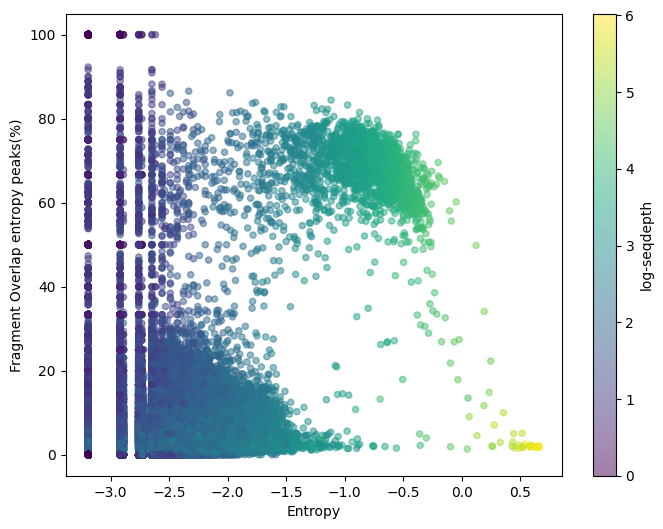

In [37]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(all_df['log(entropy)'], all_df['frag_overlap_entropy_peaks%'],c=all_df['log(total_fragments)'],
        marker='o', s= 20, alpha=0.5)
ax.set_xlabel('Entropy')
ax.set_ylabel('Fragment Overlap entropy peaks(%)')
fig.colorbar(ax.collections[0], ax=ax, label='log-seqdepth')

## based on entropy cutoff to see tn5 insertion differences 



/tmp/ipykernel_4062984/67428764.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc='upper right', fontsize='small')
/tmp/ipykernel_4062984/67428764.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='upper right', fontsize='small')


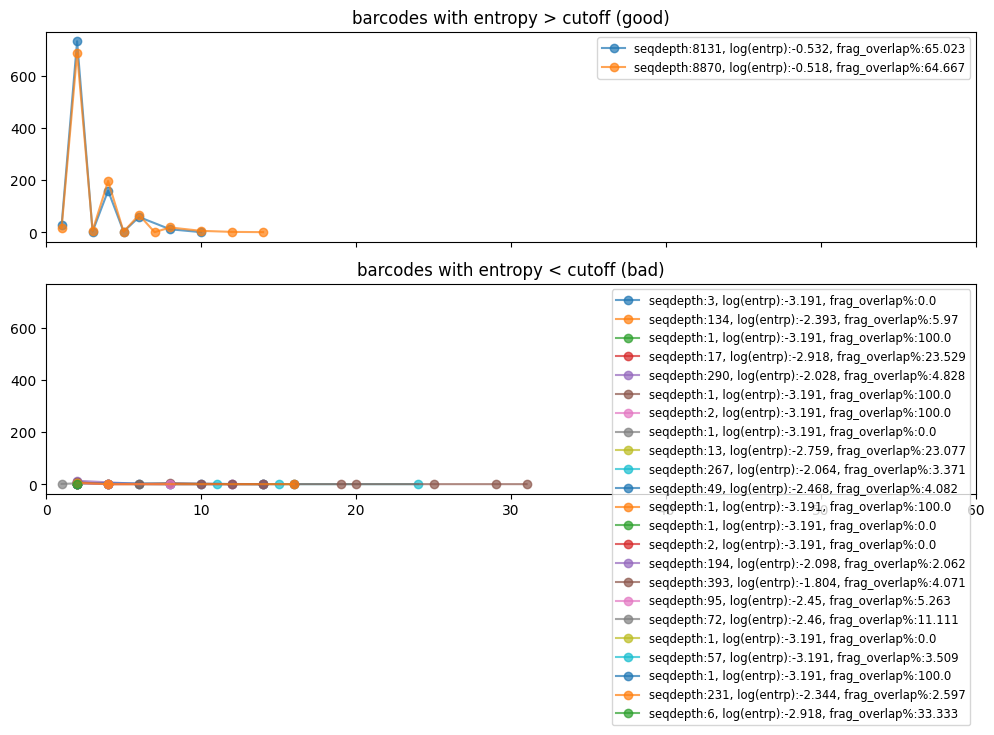

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True, sharey=True)

ax[0].set_xlim(0, 60)
ax[0].legend(loc='upper right', fontsize='small')
ax[0].set_title('barcodes with entropy > cutoff (good)')

ax[1].set_xlim(0, 60)
ax[1].legend(loc='upper right', fontsize='small')
ax[1].set_title('barcodes with entropy < cutoff (bad)')

bcs = all_df.index.tolist()

for i in range(30, 1000):
    np.random.seed(i) 
    
    sample = np.random.choice(bcs, size=1, replace=False)
    
    if sample[0] not in tn5_insert_freq.keys():
        continue
    
    insert_freq = tn5_insert_freq[sample[0]].toarray()
    seq_depth = all_df.loc[sample, 'total_fragments_peaks'].iloc[0]
    logentropy_val = all_df.loc[sample, 'log(entropy)'].iloc[0]
    frag_overlap = all_df.loc[sample, 'frag_overlap_entropy_peaks%'].iloc[0]
    
    # if bc_seq_depth > 10000:
    #     continue
    val, freq = np.unique(tn5_insert_freq[sample[0]].toarray(), return_counts=True)    
    
    if logentropy_val > np.log10(entropy_cutoff + precision):
        ax_sel = ax[0]
        plot_prob = 1.
    elif logentropy_val < np.log10(entropy_cutoff + precision):
        ax_sel = ax[1]
        plot_prob = 0.05
    
    if np.random.uniform(0,1) > plot_prob:
        continue
    ax_sel.plot(val[1:], freq[1:], marker='o', label=f'seqdepth:{seq_depth}, log(entrp):{np.round(logentropy_val, 3)}, frag_overlap%:{np.round(frag_overlap, 3)}', alpha=0.7)


ax[0].legend(loc='upper right', fontsize='small')
ax[1].legend(loc='upper right', fontsize='small')

(-4.0, 1.0)

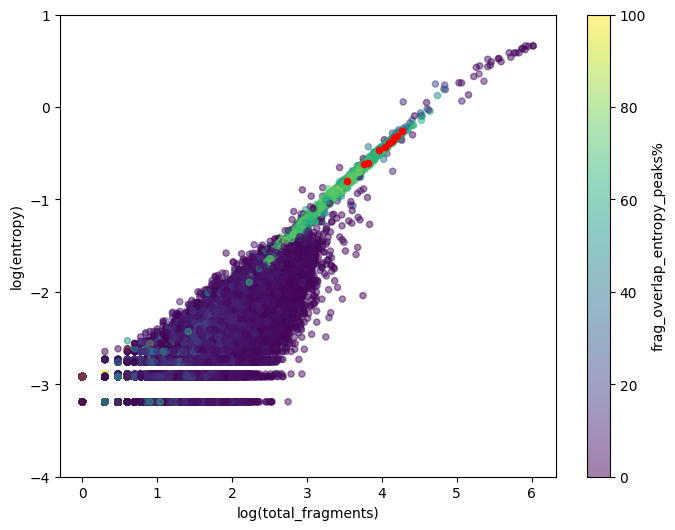

In [39]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter( all_df['log(total_fragments)'], all_df['log(entropy)'], c=all_df['frag_overlap_entropy_peaks%'],
        marker='o', s= 20, alpha=0.5)
ax.set_xlabel('log(total_fragments)')
ax.set_ylabel('log(entropy)')
ax.scatter(sim_doublet_df['log(total_fragments)'], sim_doublet_df['log(entropy)'], color='red', s=20, label='sim doublet')
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')
ax.set_ylim(-4, 1)